# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


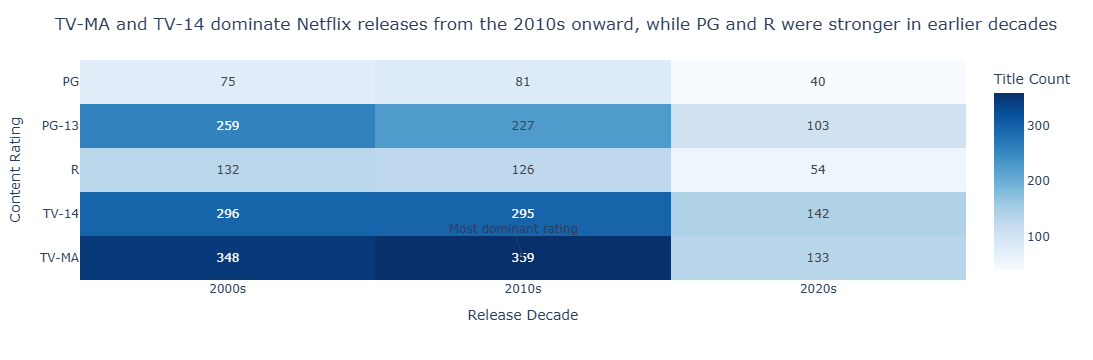

In [3]:
# Task 1
# YOUR CODE HERE
# -----------------------------


# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Keep only the most common ratings
selected_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

heatmap_df = df[df['rating'].isin(selected_ratings)]

# Count titles by rating and decade
heatmap_counts = (
    heatmap_df.groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

# Convert to matrix form
heatmap_matrix = heatmap_counts.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

# Create heatmap
fig = px.imshow(
    heatmap_matrix,
    text_auto=True,
    color_continuous_scale='Blues',   # Sequential scale for counts
    aspect='auto',
    labels=dict(color='Title Count')
)

# Insight-focused title
fig.update_layout(
    title='TV-MA and TV-14 dominate Netflix releases from the 2010s onward, while PG and R were stronger in earlier decades',
    xaxis_title='Release Decade',
    yaxis_title='Content Rating',
    template='plotly_white'
)

# Direct annotation
fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Most dominant rating',
    showarrow=True,
    arrowhead=2
)

fig.show()


Insight : The heatmap shows that TV-MA and TV-14 became the dominant content ratings on Netflix from the 2010s onward. Earlier decades had fewer titles overall, with PG and R ratings appearing more frequently in older releases. The strong concentration of darker blue shades in recent decades highlights Netflix’s rapid expansion in mature and teen-focused content. This suggests a strategic shift toward binge-worthy drama, thriller, and adult-oriented entertainment. Overall, the platform increasingly prioritised modern audience preferences as its catalogue grew globally.

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


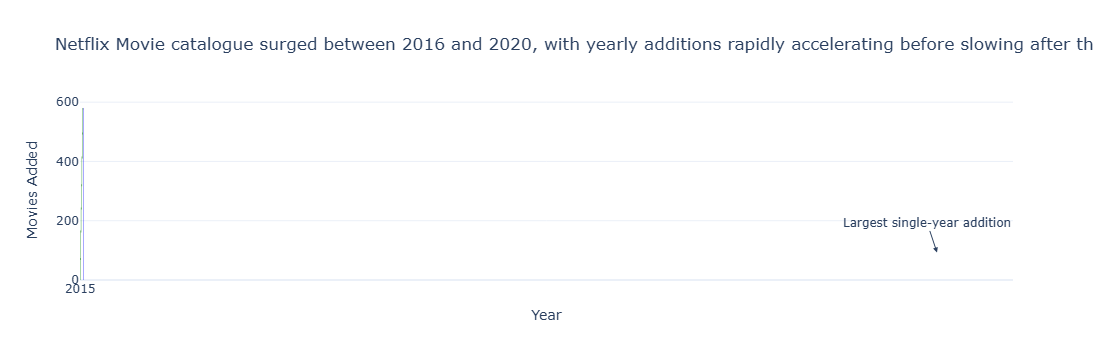

In [16]:
# Task 2
# YOUR CODE HERE
# -----------------------------


# Filter to Movies only
movies_df = df[df['type'] == 'Movie']

# Count movie additions by year
waterfall_df = (
    movies_df.groupby('added_year')
    .size()
    .reset_index(name='movies_added')
)

# Keep only 2015–2022
waterfall_df = waterfall_df[
    (waterfall_df['added_year'] >= 2015) &
    (waterfall_df['added_year'] <= 2022)
]

# Sort years
waterfall_df = waterfall_df.sort_values('added_year')

# Create measure list
measure = ['relative'] * len(waterfall_df)
measure[-1] = 'total'   # Final bar becomes cumulative total

# Create waterfall chart
fig = go.Figure(
    go.Waterfall(
        name='Movie Growth',

        orientation='v',

        measure=measure,

        x=waterfall_df['added_year'].astype(str).tolist() + ['Total'],

        y=waterfall_df['movies_added'].tolist() + [0],

        text=waterfall_df['movies_added'].tolist() + ['Total'],
        textposition='outside',

        # Required colours
        increasing={"marker": {"color": "green"}},
        decreasing={"marker": {"color": "red"}},
        totals={"marker": {"color": "blue"}}
    )
)

# Insight-focused title
fig.update_layout(
    title='Netflix Movie catalogue surged between 2016 and 2020, with yearly additions rapidly accelerating before slowing after the peak',
    xaxis_title='Year',
    yaxis_title='Movies Added',
    template='plotly_white'
)

# Find largest yearly addition
max_row = waterfall_df.loc[
    waterfall_df['movies_added'].idxmax()
]

# Add annotation
fig.add_annotation(
    x=str(max_row['added_year']),
    y=max_row['movies_added'],
    text='Largest single-year addition',
    showarrow=True,
    arrowhead=2
)

fig.show()


        

Insight : The waterfall chart reveals that Netflix’s Movie library experienced its fastest growth between 2016 and 2020. Each green bar represents strong yearly additions, showing how aggressively Netflix expanded its catalogue during this period. The largest yearly jump indicates the platform’s peak investment phase in acquiring and producing movie content. After 2020, the growth pattern begins to stabilise, suggesting a slowdown compared to earlier expansion years. The final blue total bar highlights the massive cumulative growth achieved across the 2015–2022 period.